# 02. Regression: Time-to-Failure prediction

Two models compared on the same preprocessing pipeline:
1. **Random forest** with 500 bagged trees, min leaf size 120, original feature scale
2. **Stepwise quadratic regression** with forward/backward selection on a
   quadratic candidate set, normalised features

Preprocessing steps (shared):
- Trailing moving-average smoothing (window = 3) on each sensor, per engine
- TTF cap at 125 cycles (piecewise-linear RUL. Heimes, 2008)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import (
    load_data, smooth_sensors_per_engine, cap_ttf,
    fit_zscore, apply_zscore, last_cycle_per_engine,
    FEATURE_COLS, SENSOR_COLS, TTF_CAP,
)
from src.regression import (
    train_random_forest, predict_clip,
    stepwise_quadratic, stepwise_predict, format_stepwise_formula,
)
from src.evaluation import (
    regression_metrics, plot_prediction_band, plot_residual_density,
)

train, test, y_true_test = load_data('../data')

## Preprocessing

In [2]:
train_s = smooth_sensors_per_engine(train)
test_s  = smooth_sensors_per_engine(test)

# Random forest uses the smoothed cycles on their original scale
X_train = train_s[FEATURE_COLS]
y_train = cap_ttf(train_s['ttf'].values, cap=TTF_CAP)

# For the test set, use only the last available cycle per engine
X_test_last = last_cycle_per_engine(test_s)[FEATURE_COLS]
y_true_test_capped = cap_ttf(y_true_test, cap=TTF_CAP)

print('Training rows :', len(X_train))
print('Test engines  :', len(X_test_last))

Training rows : 20631
Test engines  : 100


## Random forest

In [3]:
rf = train_random_forest(X_train, y_train,
                         n_estimators=500, min_samples_leaf=120,
                         random_state=42)

pred_rf_train = predict_clip(rf, X_train)
pred_rf_test  = predict_clip(rf, X_test_last)

rf_train = regression_metrics(y_train, pred_rf_train)
rf_test  = regression_metrics(y_true_test_capped, pred_rf_test)
print('Random forest. train:', {k: round(v, 4) for k, v in rf_train.items()})
print('Random forest. test :', {k: round(v, 4) for k, v in rf_test.items()})

Random forest. train: {'MAE': 12.0033, 'RMSE': 17.1827, 'R2': 0.83}
Random forest. test : {'MAE': 15.8944, 'RMSE': 20.5043, 'R2': 0.7382}


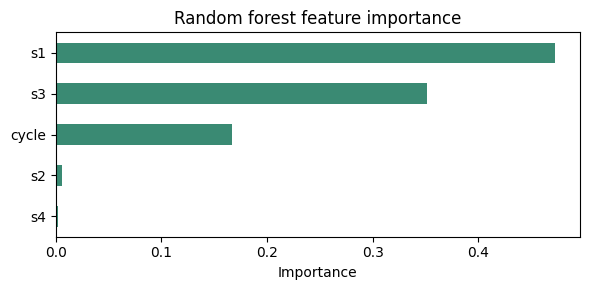

In [4]:
# Feature importance
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
fig, ax = plt.subplots(figsize=(6, 3))
imp.sort_values().plot.barh(ax=ax, color='#3a8a73')
ax.set_xlabel('Importance')
ax.set_title('Random forest feature importance')
plt.tight_layout()
plt.savefig('../figures/05_rf_feature_importance.png', dpi=150)
plt.show()

## Stepwise quadratic regression

Inputs are z-score normalised using training statistics, so the regression
coefficients are directly comparable.

In [5]:
mu, sigma = fit_zscore(X_train)
X_train_n = pd.DataFrame(apply_zscore(X_train.values, mu, sigma),
                         columns=FEATURE_COLS)
X_test_n  = pd.DataFrame(apply_zscore(X_test_last.values, mu, sigma),
                         columns=FEATURE_COLS)

sw_model, sw_terms = stepwise_quadratic(X_train_n, y_train,
                                        feature_names=FEATURE_COLS)
print('Selected terms:', sw_terms)
print(format_stepwise_formula(sw_model, sw_terms))

Selected terms: ['cycle', 's1', 'cycle^2', 's3', 'cycle:s3', 'cycle:s1', 's2', 's4', 'cycle:s2', 's1:s2', 's4^2']
TTF = 84.4956 - (17.0118 * cycle) - (7.4903 * s1) + (10.4856 * cycle^2) - (9.2043 * s3) - (5.7366 * cycle:s3) - (4.6750 * cycle:s1) + (3.3432 * s2) + (2.3127 * s4) + (2.3581 * cycle:s2) - (0.9063 * s1:s2) - (0.5367 * s4^2)


In [6]:
pred_sw_train = stepwise_predict(sw_model, sw_terms, X_train_n)
pred_sw_test  = stepwise_predict(sw_model, sw_terms, X_test_n)

sw_train = regression_metrics(y_train, pred_sw_train)
sw_test  = regression_metrics(y_true_test_capped, pred_sw_test)
print('Stepwise. train:', {k: round(v, 4) for k, v in sw_train.items()})
print('Stepwise. test :', {k: round(v, 4) for k, v in sw_test.items()})

Stepwise. train: {'MAE': 14.756, 'RMSE': 18.7353, 'R2': 0.7979}
Stepwise. test : {'MAE': 16.6348, 'RMSE': 20.6535, 'R2': 0.7344}


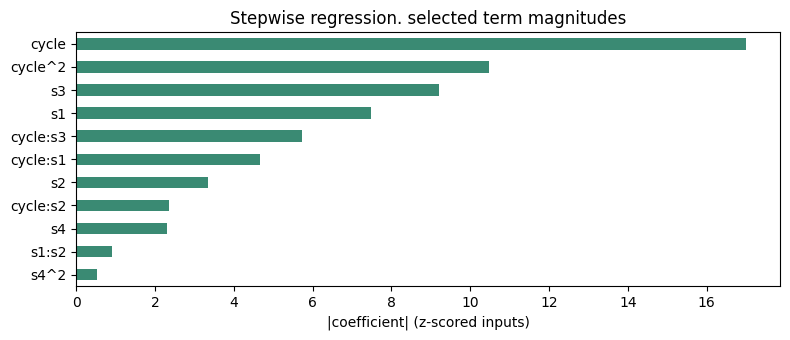

In [7]:
# Selected-term coefficients
coefs = sw_model.params.drop('const').abs()
fig, ax = plt.subplots(figsize=(8, 3.5))
coefs.sort_values().plot.barh(ax=ax, color='#3a8a73')
ax.set_xlabel('|coefficient| (z-scored inputs)')
ax.set_title('Stepwise regression. selected term magnitudes')
plt.tight_layout()
plt.savefig('../figures/06_stepwise_coefficients.png', dpi=150)
plt.show()

## Predictions vs. ground truth

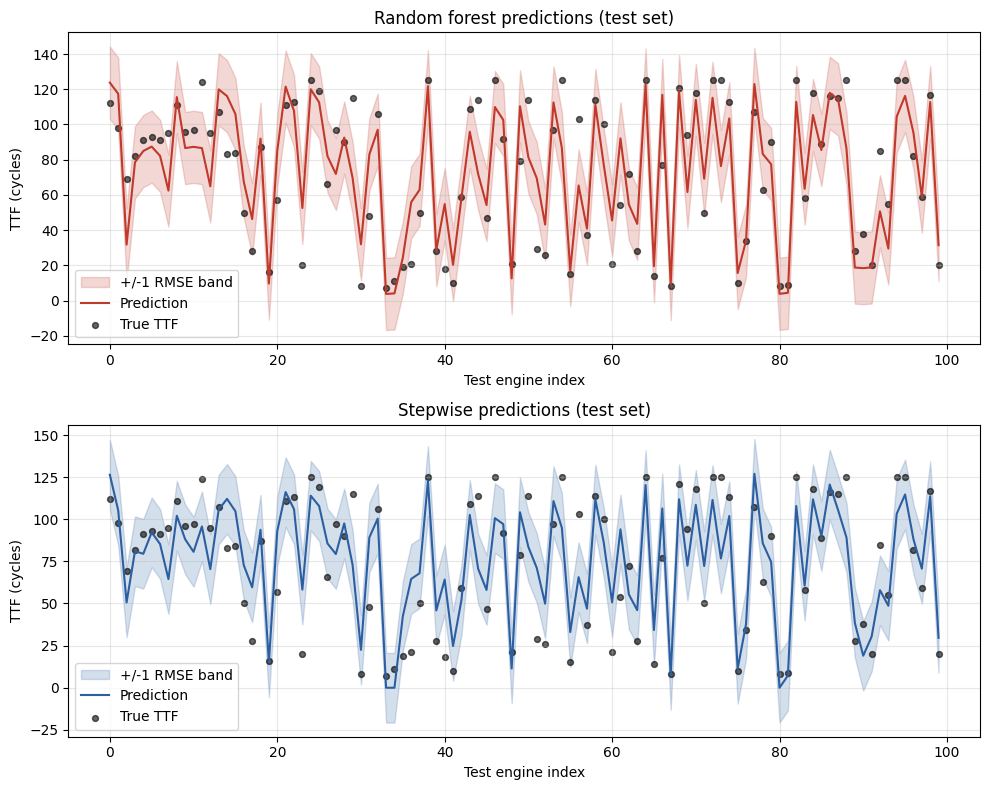

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_prediction_band(pred_rf_test, y_true_test_capped, rf_test['RMSE'],
                     'Random forest predictions (test set)', color='#c0392b',
                     ax=axes[0])
plot_prediction_band(pred_sw_test, y_true_test_capped, sw_test['RMSE'],
                     'Stepwise predictions (test set)', color='#2c5fa1',
                     ax=axes[1])
plt.tight_layout()
plt.savefig('../figures/07_predictions_vs_truth.png', dpi=150)
plt.show()

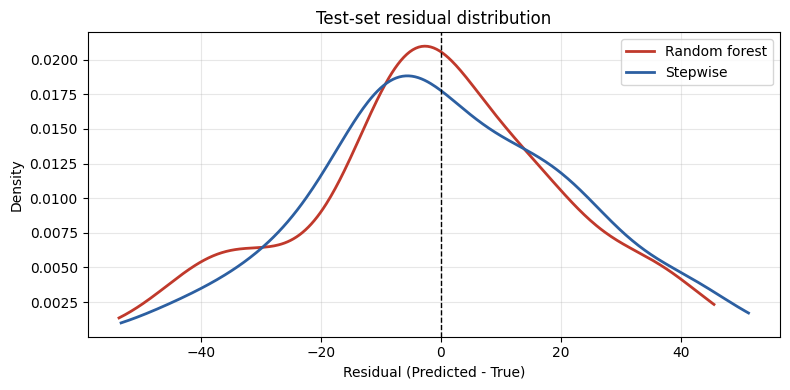

In [9]:
# Residual density
res_rf = pred_rf_test - y_true_test_capped
res_sw = pred_sw_test - y_true_test_capped

fig, ax = plt.subplots(figsize=(8, 4))
plot_residual_density(
    {'Random forest': (res_rf, '#c0392b'),
     'Stepwise': (res_sw, '#2c5fa1')},
    ax=ax,
)
ax.set_title('Test-set residual distribution')
plt.tight_layout()
plt.savefig('../figures/08_residual_density.png', dpi=150)
plt.show()

In [10]:
# Final results table
table = pd.DataFrame({
    'Stepwise (train)': sw_train,
    'Stepwise (test)' : sw_test,
    'RF (train)'      : rf_train,
    'RF (test)'       : rf_test,
}).round(4)
table

,Stepwise (train),Stepwise (test),RF (train),RF (test)
MAE,14.7560,16.6348,12.0033,15.8944
RMSE,18.7353,20.6535,17.1827,20.5043
R2,0.7979,0.7344,0.8300,0.7382


Random forest gives slightly lower error and a narrower residual band on the
test set, which suggests the non-linear degradation pattern is better captured
by the tree ensemble than by the quadratic regression.